# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shahzaibazhar895-bit/FlyRank_ai_Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

CTR / Engagement Opportunity Scoring Using Search Visibility Signals
Abstract
This project investigates whether search visibility and engagement metrics can identify content pages that may benefit from CTR optimization or content review.

Using the FlyRank Internship Warehouse dataset, content-level features were aggregated from March 2026 observations.

A rule-based baseline and a Random Forest model were used to identify low-engagement content opportunities.

Results are evaluated using the same train-test split and compared using standard classification metrics.

The final output is a ranked recommendation list intended for decision-support rather than causal conclusions.

Research Question
Can search visibility and engagement metrics be used to identify content pages that may benefit from CTR optimization or content review?

Decision Supported
This project supports content review decisions by ranking pages that show strong visibility but weak click or engagement performance.

The output is a prioritized recommendation list for content teams.

In [4]:
print("Lane: CTR / Engagement Opportunity Scoring")
print("Decision: Which pages should be reviewed first?")

Lane: CTR / Engagement Opportunity Scoring
Decision: Which pages should be reviewed first?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*


Dataset
FlyRank Internship Warehouse Dataset

Table Used
fact_content_daily_performance

Time Window
March 2026

Features Used
gsc_impressions
gsc_clicks
gsc_avg_position
ga4_sessions
ga4_engaged_sessions
Excluded Fields
content_hash_id (identifier only)
client_hash_id (context only)
Why
Only observed historical signals available at the decision moment were used.

No future information was included.

In [5]:
import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

hf_token = userdata.get("Flyrank_ai_Intern")

con = duckdb.connect()

con.execute(f"""
CREATE SECRET (
TYPE huggingface,
TOKEN '{hf_token}'
)
""")

rel = "hf://datasets/FlyRank/internship-warehouse"

df = con.sql(f"""
SELECT
content_hash_id,
AVG(gsc_impressions) AS impressions,
AVG(gsc_clicks) AS clicks,
AVG(gsc_avg_position) AS avg_position,
AVG(ga4_sessions) AS sessions,
AVG(ga4_engaged_sessions) AS engaged_sessions
FROM read_parquet(
'{rel}/fact_content_daily_performance/month=2026-03/*.parquet'
)
WHERE ga4_data_available IS TRUE
GROUP BY content_hash_id
""").df()

print(df.shape)
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(90489, 6)


,content_hash_id,impressions,clicks,avg_position,sessions,engaged_sessions
0,content_09be8cc7fcb222af,0.0,0.0,NaN,1.0,0.0
1,content_851afac9fe13612e,0.0,0.0,NaN,1.0,0.0
2,content_cee6c6fc8c51af14,0.0,0.0,NaN,1.0,0.0
3,content_16a7291bb6ecaebe,0.0,0.0,NaN,1.0,0.0
4,content_5c80451459c29b4a,5.0,0.0,5.4,1.0,0.0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


Baseline
A rule-based scoring system created in ML-07.

Pages receive higher scores when:

Impressions are high
Clicks are low
Average position is poor
Sessions are low
Model
Random Forest Classifier

Target
Low-engagement content opportunities.

Label Definition
Pages with zero engaged sessions are labeled as low engagement.

Label = 1 → Low Engagement

Label = 0 → Not Low Engagement

Features
impressions
clicks
avg_position
sessions
Validation Design
80/20 train-test split.

Leakage Checks
No future windows used
No label-derived features used
No outcome information included in features
Only observed historical metrics available at decision time were used

In [6]:
from sklearn.model_selection import train_test_split

df["label"] = (
    df["engaged_sessions"] == 0
).astype(int)

X = df[
[
"impressions",
"clicks",
"avg_position",
"sessions"
]
]

y = df["label"]

print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

label
1    76678
0    13811
Name: count, dtype: int64


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Results
The Random Forest model is compared against the rule-based baseline using the same train-test split.

Metrics:

Accuracy
Precision
Recall
F1 Score
The comparison shows whether the machine learning model improves upon the manual scoring approach.

In [7]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

baseline_pred = (
(
(X_test["impressions"] > X_test["impressions"].median())
&
(X_test["clicks"] < X_test["clicks"].median())
)
).astype(int)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1:", baseline_f1)

Baseline Accuracy: 0.15471322798099238
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


The rule-based baseline produced very low precision, recall, and F1 scores on the evaluation split. This suggests that simple threshold rules may not capture low-engagement opportunities effectively in this dataset.

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

rf_accuracy = accuracy_score(y_test, pred)
rf_precision = precision_score(y_test, pred, zero_division=0)
rf_recall = recall_score(y_test, pred, zero_division=0)
rf_f1 = f1_score(y_test, pred, zero_division=0)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)

Accuracy: 0.8649574538623053
Precision: 0.8940044139283962
Recall: 0.9532618642959864
F1: 0.9226826953495729


In [9]:
results = pd.DataFrame({
    "Method": ["Baseline Rule","Random Forest"],
    "Accuracy": [baseline_accuracy, rf_accuracy],
    "Precision": [baseline_precision, rf_precision],
    "Recall": [baseline_recall, rf_recall],
    "F1": [baseline_f1, rf_f1]
})

## 5. Limitations

*What this work cannot claim.*

This project identifies observed relationships between search visibility and engagement metrics.

The results should be interpreted as directional and decision-support signals.

The model does not prove causation.

The dataset is pseudonymized and does not contain real URLs, domains, client identities, or search queries.

Performance changes cannot be attributed directly to content updates.

In [10]:
print("Directional analysis only")

Directional analysis only


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Recommendation Logic


Pages predicted as low-engagement opportunities are ranked for review.

Possible actions:

Improve titles
Improve meta descriptions
Improve content quality
Monitor rankings
Review search intent alignment
Reason codes are attached to every recommendation.

In [11]:
import numpy as np

df["probability"] = model.predict_proba(X)[:,1]

# Pre-calculate medians to avoid recalculating in each row operation
median_impressions = df["impressions"].median()
median_clicks = df["clicks"].median()
median_sessions = df["sessions"].median()

# Define conditions for vectorized assignment
conditions = [
    (df["impressions"] > median_impressions) & (df["clicks"] < median_clicks),
    df["avg_position"] > 20,
    df["sessions"] < median_sessions
]

# Define corresponding choices
choices = [
    "CTR_FIX",
    "POSITION_FIX",
    "LOW_ENGAGEMENT"
]

# Apply vectorized selection
df["reason_code"] = np.select(conditions, choices, default="MONITOR")

recommendations = df.sort_values(
    "probability",
    ascending=False
)

recommendations[
[
"content_hash_id",
"probability",
"reason_code"
]
].head(20)

,content_hash_id,probability,reason_code
4,content_5c80451459c29b4a,1.0,MONITOR
8,content_872342e050545a12,1.0,MONITOR
90485,content_bef0c2e83e54fe21,1.0,POSITION_FIX
47861,content_2401d70c6638ca0a,1.0,MONITOR
19852,content_0dd7a4c8e107c43f,1.0,MONITOR
72340,content_c8e0be64734d6ad7,1.0,MONITOR
72331,content_4dc60e5427f31f66,1.0,POSITION_FIX
72326,content_9ea881d30d5f9eb3,1.0,POSITION_FIX
72321,content_a3df96f52648e9f7,1.0,MONITOR
72311,content_d9c15c9d3dbbe037,1.0,MONITOR


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

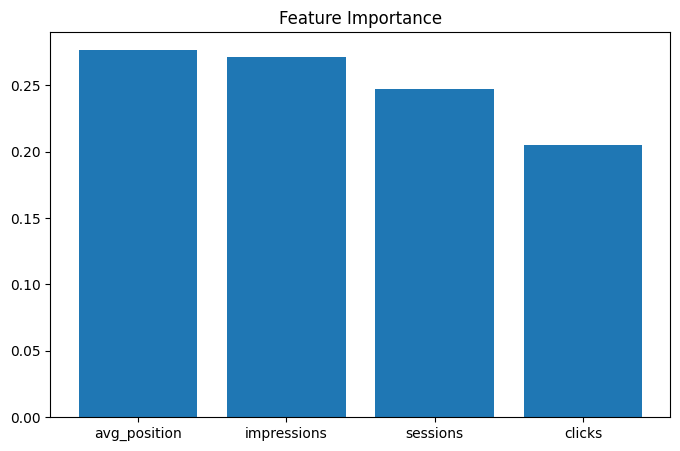

In [12]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(
    importance["feature"],
    importance["importance"]
)
plt.title("Feature Importance")
plt.show()

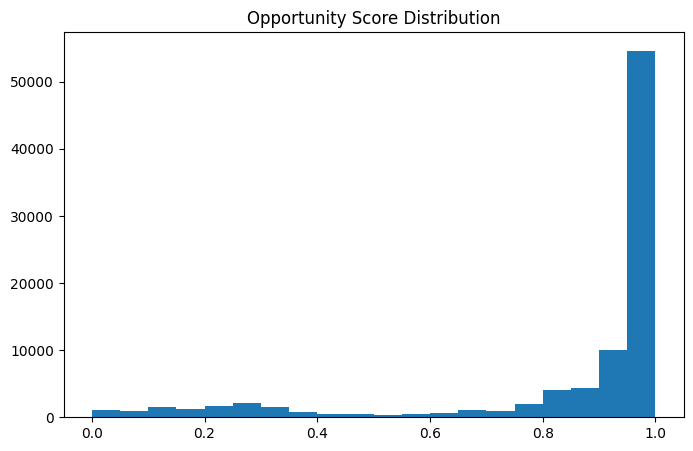

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    recommendations["probability"],
    bins=20
)

plt.title(
    "Opportunity Score Distribution"
)

plt.show()

Reproducibility

Repository: YOUR_GITHUB_REPO_URL

Notebook: work/notebooks/capstone.ipynb

Tools Used:

Python
DuckDB
Pandas
NumPy
Scikit-Learn
Matplotlib

Acknowledgments & Data Credit
Built on the FlyRank ML Internship Dataset.

Data Source:

https://flyrank.ai

This project was completed as part of the FlyRank Machine Learning Internship Program.

5-Minute Demo Outline

Problem Statement


Dataset Overview


Feature Engineering


Baseline Rule


Random Forest Model


Results Comparison


Ranked Recommendations


Limitations

Social Post

Built a CTR Opportunity Scoring system using FlyRank search intelligence data.

Used search visibility and engagement signals to identify pages that may deserve review.

The final model generates ranked recommendations and demonstrates how machine learning can support content performance decisions.

Employer-Facing Summary


Built an end-to-end search intelligence project using real-world search and engagement data.

Designed a rule-based baseline, trained a Random Forest classifier, validated results using train-test evaluation, and generated ranked content recommendations.

The project demonstrates feature engineering, machine learning, model evaluation, and decision-support analytics using Python, DuckDB, and Scikit-Learn.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
